[코스모화학]의 데이터를 가져오는 중...
[코스모화학]의 데이터 수집 완료! (데이터 수 : 1513개)
[코스모화학]의 전략 수익률 및 기본 수익률 계산 완료!


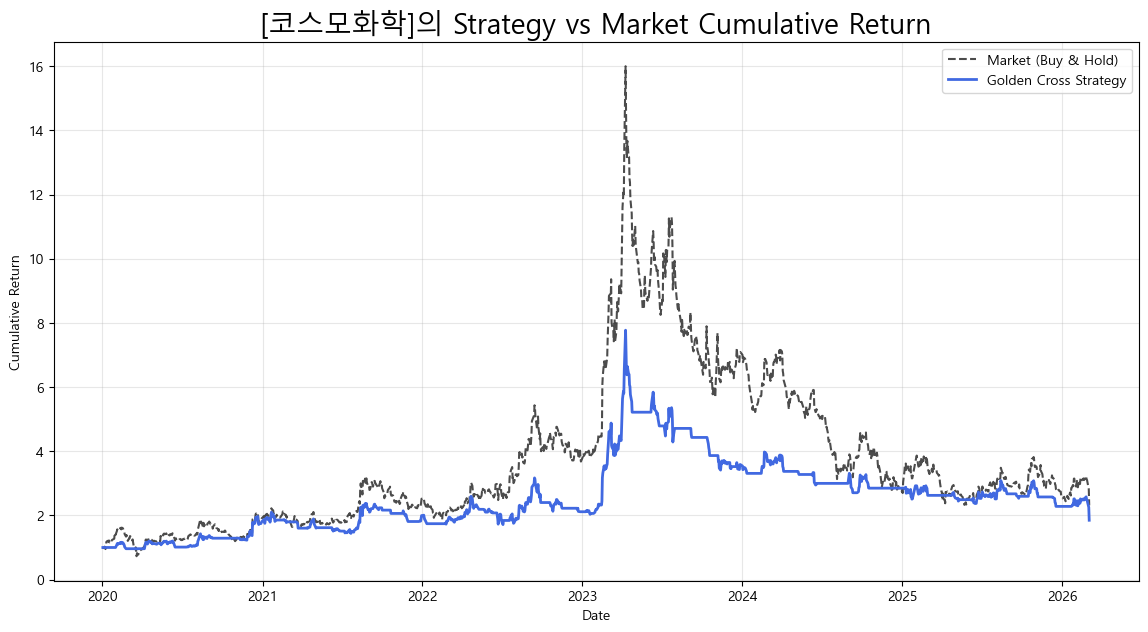


           [코스모화학의 최종 수익률]          
Buy & Hold 시 수익률: 2.31배
Golden Cross 전략 시 수익률: 1.85배
----------------------------------------
결과: 시장에 졌습니다. 다른 전략이 필요합니다.

엑셀파일 저장위치: C:\WINDOWS\system32\코스모화학_골든크로스전략과시장수익률비교.xlsx


In [10]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd
import os

#한글 깨짐 방지 코드
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class StockAnalyzer:
    
    #시작할 때 한번만 실행
    def __init__(self, code, name):
        self.code = code
        self.name = name
        self.df = None #일단 비워둔다.
        
    #원하는 종목의 원하는 날짜부터 데이터를 데이터프레임에 저장한다.
    def fetch_data(self, start_date):
        print(f"[{self.name}]의 데이터를 가져오는 중...")
        self.df = fdr.DataReader(self.code, start_date)
        print(f"[{self.name}]의 데이터 수집 완료! (데이터 수 : {len(self.df)}개)")

    #매매 전략의 수익률을 계산 여기서는 5일선이 20일선을 돌파하는 골든크로스일때 매수하는 전략
    def apply_strategy(self):
        if self.df is None: return #self.df가 비어있으면 실행이 안되고 나감. 즉 fetch_data를 해야만 실행됨.
        
        self.df['MA5'] = self.df['Close'].rolling(window=5).mean() #5일 이동평균선
        self.df['MA20'] = self.df['Close'].rolling(window=20).mean() #20일 이동평균선
        
        self.df['Signal'] = (self.df['MA5']>self.df['MA20']).astype(int) #5일선이 20일선보다 크면 TRUE. 즉 1로 저장 아니면 0
        
        self.df['Daily_Return'] = self.df['Close'].pct_change() #전 거래일의 종가 대비 당일 종가의 증가율
        #전략 실행 시 수익률. 전날의 signal로 당일의 매매를 결정하기 때문에 shift를 해줌
        self.df['Strategy_Return'] = (self.df['Daily_Return']*self.df['Signal'].shift(1))

        #쭉 들고있었을 때 수익률과 전략 실행 시 수익률
        self.df['Cum_Daily_Return'] = (1 + self.df['Daily_Return'].fillna(0)).cumprod() #비어있는 데이터는 0으로 교체
        self.df['Cum_Strategy_Return'] = (1 + self.df['Strategy_Return'].fillna(0)).cumprod()

        print(f"[{self.name}]의 전략 수익률 및 기본 수익률 계산 완료!")

    #수익률 결과를 그래프로 확인
    def visualize_results(self):
        if self.df is None: return

        plt.figure(figsize=(14, 7)) #그래프 사이즈 설정

        #각 수익률 그래프 설정
        plt.plot(self.df['Cum_Daily_Return'], label='Market (Buy & Hold)', color='black', linestyle='--', alpha = 0.7)
        plt.plot(self.df['Cum_Strategy_Return'], label='Golden Cross Strategy', color='royalblue', linewidth=2)

        plt.title(f"[{self.name}]의 Strategy vs Market Cumulative Return", fontsize=20)
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def compare_with_market(self):
        if self.df is None: return

        #최종 누적 수익률로 데이터 프레임 마지막칸에 있는 데이터를 불러온다.
        final_market = self.df['Cum_Daily_Return'].iloc[-1]
        final_strategy = self.df['Cum_Strategy_Return'].iloc[-1]

        print(f"\n" + "="*40)
        print(f"           [{self.name}의 최종 수익률]          ")
        print(f"Buy & Hold 시 수익률: {final_market:.2f}배")
        print(f"Golden Cross 전략 시 수익률: {final_strategy:.2f}배")
        print("-"*40)

        if final_strategy > final_market:
            print("결과: 시장을 이겼습니다.")
        else:
            print("결과: 시장에 졌습니다. 다른 전략이 필요합니다.")

        print("="*40)

#-------------------실행 부분------------------------------

#데이터 가져오기
cosmo_chemical = StockAnalyzer('005420', '코스모화학')
cosmo_chemical.fetch_data('2020-01-01')

#수익률 계산
cosmo_chemical.apply_strategy()

#그래프로 시각화
cosmo_chemical.visualize_results()

#최종 수익률 비교 결과 확인
cosmo_chemical.compare_with_market()

#엑셀로 저장
file_name = f"{cosmo_chemical.name}_골든크로스전략과시장수익률비교.xlsx"
cosmo_chemical.df.to_excel(file_name)
full_path = os.path.abspath(file_name)

print("\n" + "="*40)
print(f"엑셀파일 저장위치: {full_path}")
print("="*40)